# Agrégation de la tache urbaine 2022 sur le carroyage 200 m (Grand Genève)

Chaque carreau qui **intersecte** la tache urbaine reçoit `urbain = 1`, les autres `urbain = 0`.

- Entrées : `AGGLO_CARREAU_200.shp` (carroyage 200 m) et `AGGLO_TACHE_URBAINE_2022.gpkg` (tache urbaine)
- Sortie : `AGGLO_CARREAU_200_urbain.gpkg` (carroyage complet + colonne `urbain`)

In [1]:
from pathlib import Path
import geopandas as gpd

# Adapter si besoin




import geopandas as gpd
import os

operation_crs = "EPSG:2056"  # Swiss coordinate system
target_crs = "EPSG:4326"  # WGS84 coordinate system

print("Set parameters : GG or GE, bike or walk")
territory = 'GG' # GG or GE
network = "walk"  # walk or bike
type="unweighted" # fixer unweighted
index_col = f"{network}_index" 

input_file_path = '../../Data/input'
output_step1_path=f"../../Data/output/{network}/{territory}/step-1"
output_step2_path=f"../../Data/output/{network}/{territory}/step-2"
output_step3_path=f"../../Data/output/{network}/{territory}/step-3_{type}"
save_path = f"../../Data/output/{network}/{territory}/geographic_weighting"



#Read the files
index = gpd.read_parquet(f'{output_step3_path}/step3_index.parquet')
index = index.to_crs(operation_crs)


agglo_carreau = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_CARREAU_200-SHP/AGGLO_CARREAU_200.shp')
agglo_carreau = agglo_carreau.to_crs(operation_crs)

tache = gpd.read_file(f'{input_file_path}/network_agreg/AGGLO_TACHE_URBAINE_2022.gpkg')

print("Carreaux :", agglo_carreau.shape, agglo_carreau.crs)
print("Tache    :", tache.shape, tache.crs)


Set parameters : GG or GE, bike or walk
Carreaux : (166762, 13) EPSG:2056
Tache    : (209, 11) EPSG:2056


/Users/maximiliantrique/Documents/GitHub/projet-index-walk-bike-ge-gg/venv/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


## 2. Préparation de la tache urbaine

- La couche est en `MultiPolygon ZM` : on repasse en 2D (la Z/M ne sert à rien ici).
- Certaines géométries sont invalides : on les répare avec `make_valid()` pour éviter des erreurs ou des résultats faux dans le `sjoin`.
- On vérifie que les deux couches sont dans le même système (EPSG:2056).

In [2]:
tache["geometry"] = tache.geometry.force_2d()
print("Géométries invalides avant réparation :", (~tache.is_valid).sum())
tache["geometry"] = tache.geometry.make_valid()
print("Géométries invalides après réparation :", (~tache.is_valid).sum())

if tache.crs != agglo_carreau.crs:
    tache = tache.to_crs(agglo_carreau.crs)

# On ne garde que la géométrie pour la jointure (on n'a pas besoin des attributs de la tache)
tache = tache[["geometry"]]

Géométries invalides avant réparation : 1
Géométries invalides après réparation : 0


## 3. Jointure spatiale (intersects)

Un carreau peut toucher plusieurs polygones de tache → le `sjoin` peut le dupliquer.
On récupère donc simplement l'ensemble des index de carreaux qui ont au moins une correspondance.

In [3]:
joint = gpd.sjoin(agglo_carreau, tache, how="inner", predicate="intersects")
idx_urbains = joint.index.unique()

agglo_carreau["urbain"] = 0
agglo_carreau.loc[idx_urbains, "urbain"] = 1
agglo_carreau["urbain"] = agglo_carreau["urbain"].astype("int8")

print(agglo_carreau["urbain"].value_counts().rename({1: "urbain", 0: "non urbain"}))

urbain
non urbain    147152
urbain         19610
Name: count, dtype: int64


## 4. Contrôles

In [4]:
# Même nombre de carreaux qu'en entrée, pas de doublons
assert agglo_carreau.index.is_unique
assert agglo_carreau["GRID_ID"].is_unique
assert set(agglo_carreau["urbain"].unique()) <= {0, 1}

part = agglo_carreau["urbain"].mean()
print(f"{len(agglo_carreau)} carreaux, dont {agglo_carreau['urbain'].sum()} urbains ({part:.1%})")

166762 carreaux, dont 19610 urbains (11.8%)


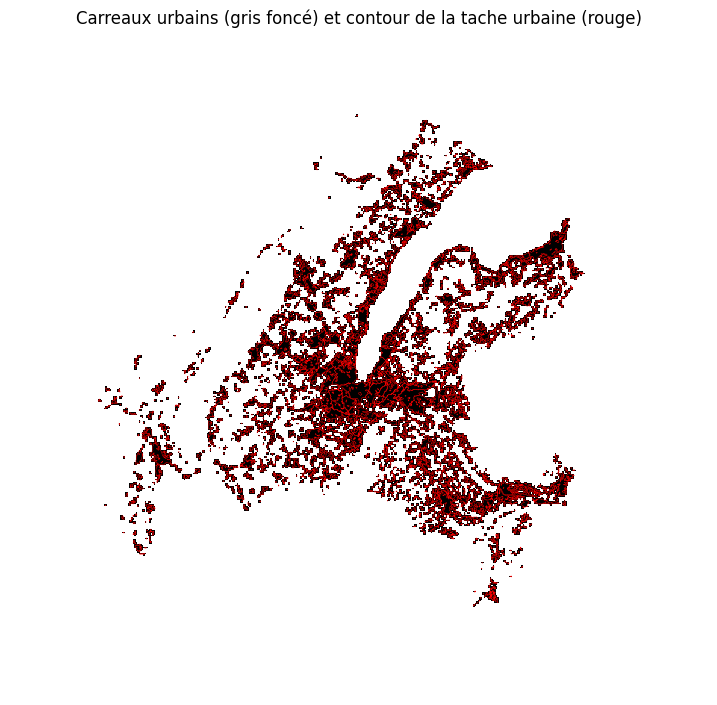

In [5]:
# Aperçu visuel
ax = agglo_carreau.plot(column="urbain", cmap="Greys", figsize=(9, 9), linewidth=0)
tache.boundary.plot(ax=ax, color="red", linewidth=0.3)
ax.set_title("Carreaux urbains (gris foncé) et contour de la tache urbaine (rouge)")
ax.set_axis_off()

## 5. Export GeoPackage

In [7]:
agglo_carreau.to_file(os.path.join(save_path, "carreau_200_urbain.gpkg"), driver="GPKG")
